In [1]:
import os
import glob
from matplotlib import pyplot as plt
import tensorflow as tf
import librosa
import numpy as np

In [2]:
# Define paths to the positive and negative sample directories
CAPUCHIN_FILE = os.path.join('dataset', 'Parsed_Capuchinbird_Clips', 'XC3776-3.wav')
NOT_CAPUCHIN_FILE = os.path.join('dataset', 'Parsed_Not_Capuchinbird_Clips', 'afternoon-birds-song-in-forest-0.wav')

In [3]:
def load_wav_16k_mono(filename):
 

    if isinstance(filename, bytes):
        filename = filename.decode('utf-8')
    

    wav, sr = librosa.load(filename, sr=16000, mono=True)
    
    return np.array(wav, dtype=np.float32)

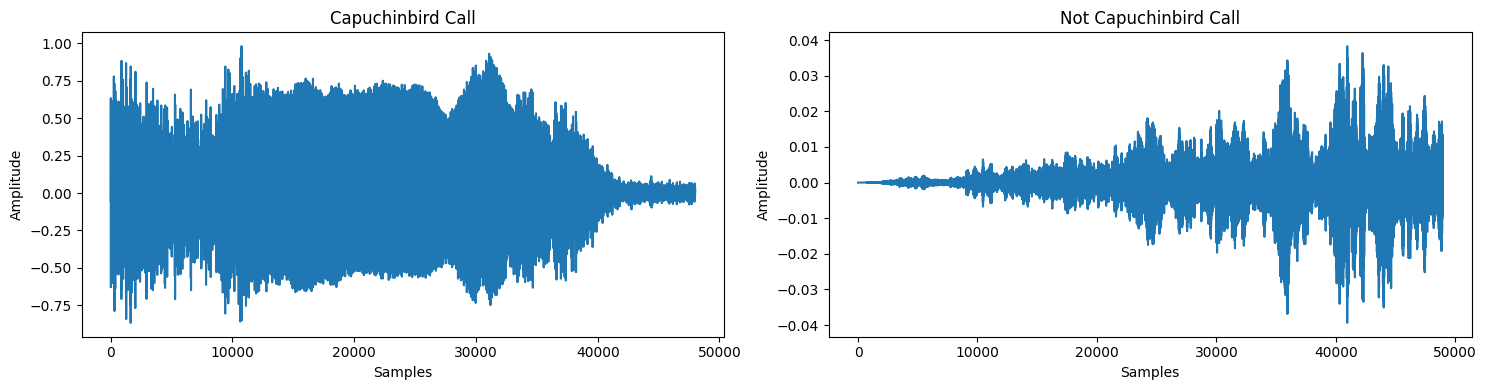

In [4]:

wave_capuchin = load_wav_16k_mono(CAPUCHIN_FILE)
wave_not_capuchin = load_wav_16k_mono(NOT_CAPUCHIN_FILE)


plt.figure(figsize=(15, 4))

plt.subplot(1, 2, 1)
plt.plot(wave_capuchin)
plt.title("Capuchinbird Call")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.subplot(1, 2, 2)
plt.plot(wave_not_capuchin)
plt.title("Not Capuchinbird Call")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [5]:

POS = os.path.join('dataset', 'Parsed_Capuchinbird_Clips')
NEG = os.path.join('dataset', 'Parsed_Not_Capuchinbird_Clips')


pos_files = glob.glob(os.path.join(POS, '*.wav'))
neg_files = glob.glob(os.path.join(NEG, '*.wav'))

pos_ds = tf.data.Dataset.from_tensor_slices(pos_files)
neg_ds = tf.data.Dataset.from_tensor_slices(neg_files)

positives = pos_ds.map(lambda x: (x, tf.constant(1.0)))
negatives = neg_ds.map(lambda x: (x, tf.constant(0.0)))


data = positives.concatenate(negatives)

In [9]:
# Calculate the lengths of all positive samples
lengths = []
for file in pos_files:
    tensor_wave = load_wav_16k_mono(file)
    lengths.append(len(tensor_wave))

In [10]:
# Calculate and print mean, min, and max lengths
print(f"Mean Length: {tf.math.reduce_mean(lengths).numpy()}")
print(f"Min Length: {tf.math.reduce_min(lengths).numpy()}")
print(f"Max Length: {tf.math.reduce_max(lengths).numpy()}")

Mean Length: 54156
Min Length: 32000
Max Length: 80000


In [15]:
def preprocess(file_path, label):
    # Load the wav file using the previously defined function
    wav = tf.numpy_function(load_wav_16k_mono, [file_path], tf.float32)
    
    # Pad or trim the audio to a fixed length of 48,000 samples (3 seconds)
    wav = wav[:48000]
    padding = tf.maximum(48000 - tf.shape(wav)[0], 0)
    wav = tf.pad(wav, paddings=[[0, padding]])

    # Compute the spectrogram
    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)
    
    # Add a channel dimension for the CNN
    spectrogram = tf.expand_dims(spectrogram, axis=2)

    # Set the shape explicitly to ensure consistency
    spectrogram.set_shape([1491, 257, 1])

    return spectrogram, label


In [16]:
data = data.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
data = data.cache()
data = data.shuffle(buffer_size=1000)
data = data.batch(4)
data = data.prefetch(buffer_size=8)

In [17]:
train_size = 36
train = data.take(train_size)
test = data.skip(train_size).take(15)

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping

# Build the CNN model
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(1491, 257, 1)),
    MaxPooling2D((4, 4)),
    Conv2D(16, (3, 3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer="Adam",
    loss="BinaryCrossentropy",
    metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

model.summary()

C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 1489, 255, 16)       │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 372, 63, 16)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 370, 61, 16)         │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 361120)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      46,223,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 46,226,097 (176.34 MB)

 Trainable params: 46,226,097 (176.34 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Setup early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train the model
hist = model.fit(
    train,
    epochs=10,
    validation_data=test,
    callbacks=[early_stop]
)


Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - loss: 7.3770 - precision: 0.5490 - recall: 0.7368 - val_loss: 0.2200 - val_precision: 0.9286 - val_recall: 0.7222
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 32s 884ms/step - loss: 0.2311 - precision: 0.9143 - recall: 0.8649 - val_loss: 0.0616 - val_precision: 0.9474 - val_recall: 0.9474
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 29s 813ms/step - loss: 0.1576 - precision: 0.9412 - recall: 0.8205 - val_loss: 0.1297 - val_precision: 1.0000 - val_recall: 0.6250
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 32s 888ms/step - loss: 0.0514 - precision: 0.9706 - recall: 0.9167 - val_loss: 0.0781 - val_precision: 1.0000 - val_recall: 0.9130
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 971ms/step - loss: 0.0926 - precision: 0.9500 - recall: 0.9048 - val_loss: 0.0302 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 29s 805ms/step - loss: 0.0808 - precision: 0.9474 - recall: 0.9000 - val_loss: 0.0217 - val_precision: 1.0000 - val_reca

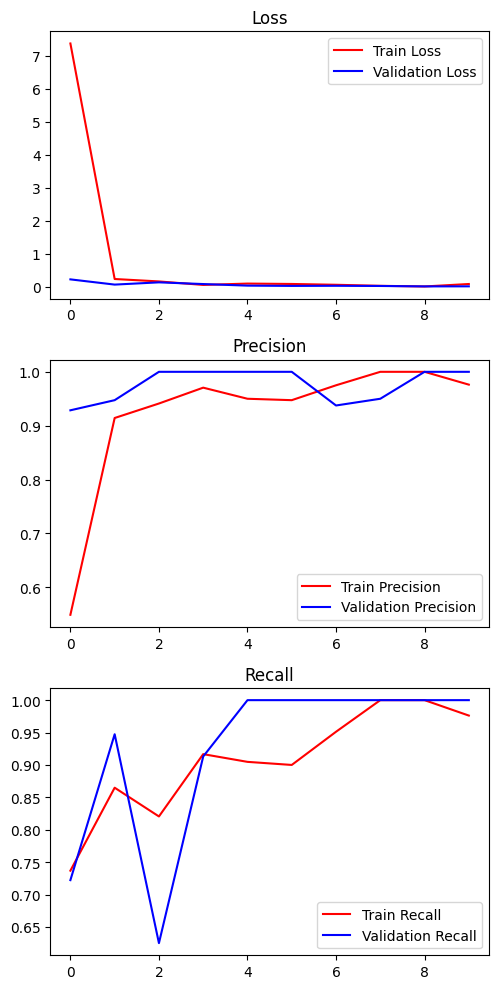

In [23]:
# Plot training history
fig, axs = plt.subplots(3, 1, figsize=(5, 10))

# Plot Loss
axs[0].set_title('Loss')
axs[0].plot(hist.history['loss'], 'r', label='Train Loss')
axs[0].plot(hist.history['val_loss'], 'b', label='Validation Loss')
axs[0].legend()

# Plot Precision
axs[1].set_title('Precision')
axs[1].plot(hist.history['precision'], 'r', label='Train Precision')
axs[1].plot(hist.history['val_precision'], 'b', label='Validation Precision')
axs[1].legend()

# Plot Recall
axs[2].set_title('Recall')
axs[2].plot(hist.history['recall'], 'r', label='Train Recall')
axs[2].plot(hist.history['val_recall'], 'b', label='Validation Recall')
axs[2].legend()

plt.tight_layout()
plt.show()

In [24]:
from itertools import groupby

def classify_audio_file(filepath, model, threshold=0.99):
    """
    Loads a long audio file, makes predictions on 3-second chunks,
    and counts the number of detection events.
    """
    # 1. Load audio file
    wav = load_wav_16k_mono(filepath)
    
    # 2. Create 3-second slices
    audio_slices = tf.keras.utils.timeseries_dataset_from_array(
        wav, wav,
        sequence_length=48000,
        sequence_stride=48000,
        batch_size=1
    )
    
    # 3. Preprocess slices into spectrograms
    def preprocess_slice(sample, index=None):
        sample = sample[0]
        padding = tf.zeros([48000] - tf.shape(sample), dtype=tf.float32)
        wav_padded = tf.concat([sample, padding], 0)
        spectrogram = tf.signal.stft(wav_padded, frame_length=320, frame_step=32)
        spectrogram = tf.abs(spectrogram)
        spectrogram = tf.expand_dims(spectrogram, axis=2)
        return spectrogram

    audio_slices = audio_slices.map(preprocess_slice)
    audio_slices = audio_slices.batch(64)
    
    # 4. Make predictions
    predictions = model.predict(audio_slices)
    
    # 5. Convert probabilities to binary classes based on a threshold
    binary_preds = [1 if pred > threshold else 0 for pred in predictions]
    
    # 6. Group consecutive detections into single events and count them
    detection_count = sum(1 for k, g in groupby(binary_preds) if k == 1)

    return {
        "file": os.path.basename(filepath),
        "predictions_per_slice": binary_preds,
        "detection_count": detection_count
    }

In [25]:
# Process all files in the Forest Recordings directory
results = {}
forest_recordings_path = 'dataset/Forest Recordings/'

for file in os.listdir(forest_recordings_path):
    if file.endswith('.mp3'):
        filepath = os.path.join(forest_recordings_path, file)
        output = classify_audio_file(filepath, model)
        results[file] = output['detection_count']

# Print the final counts for each file
print("Detection counts per file:")
for file, count in results.items():
    print(f"- {file}: {count} calls")

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step  

In [26]:
# Define the filename for the saved model
model_filename = 'best_capuchin_model.keras'

# Save the entire model to a single file
model.save(model_filename)

print(f"Model successfully saved to {model_filename}")

Model successfully saved to best_capuchin_model.keras
